In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [42]:
df = pd.read_csv("../data/SFMTA_-_Parking_Citations_&_Fines_20260209 (1).csv")
df.head()

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_53994/3034697842.py:1: DtypeWarning: Columns (9,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/SFMTA_-_Parking_Citations_&_Fines_20260209 (1).csv")


,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude
0,"""11560780T",2026 Feb 04 07:56:00 PM,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,$0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
1,"""11560776T",2026 Feb 04 07:52:00 PM,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,$0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
2,"""11561605T",2026 Feb 04 07:41:00 PM,TRC7.2.101A,FAIL DISPL,METRO FOREST HILL STATION-DOWNTOWN,NaN,NaN,$134,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
3,"""11553500T",2026 Feb 04 07:41:00 PM,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,$0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
4,"""998115893",2026 Feb 04 07:40:00 PM,TRC7.2.40,PRK PROHIB,101 05TH ST,AL,3A0C313,$108,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN


In [43]:
df["Citation Issued DateTime"] = pd.to_datetime(
    df["Citation Issued DateTime"],
    errors="coerce",
    format = "%Y %b %d %I:%M:%S %p"
)

In [44]:
df["Fine Amount"] = (
    df["Fine Amount"]
    .str.replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [45]:
df = df.dropna(subset=["Citation Issued DateTime"]).copy()

In [46]:
if "Citation Number" in df.columns:
    df = df.drop_duplicates(subset="Citation Number").copy()

In [47]:
df["year"] = df["Citation Issued DateTime"].dt.year

In [48]:
df["month"] = df["Citation Issued DateTime"].dt.month_name()

In [49]:
df["hour"] = df["Citation Issued DateTime"].dt.hour

In [50]:
df["day"] = df["Citation Issued DateTime"].dt.day_name()

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day"] = pd.Categorical(df["day"], categories=order, ordered=True)

In [11]:
df.head()

,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude,year,month,hour,day
0,"""11560780T",2026-02-04 19:56:00,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,NaN,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,Wednesday
1,"""11560776T",2026-02-04 19:52:00,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,NaN,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,Wednesday
2,"""11561605T",2026-02-04 19:41:00,TRC7.2.101A,FAIL DISPL,METRO FOREST HILL STATION-DOWNTOWN,NaN,NaN,NaN,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,Wednesday
3,"""11553500T",2026-02-04 19:41:00,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,NaN,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,Wednesday
4,"""998115893",2026-02-04 19:40:00,TRC7.2.40,PRK PROHIB,101 05TH ST,AL,3A0C313,NaN,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,Wednesday


In [51]:
yearly = (
    df.groupby('year').size().reset_index(name="citations").rename(columns={"date": "year"}).sort_values("year")
)
yearly["pct_change"] = yearly["citations"].pct_change() * 100

Text(0, 0.5, 'Citations')

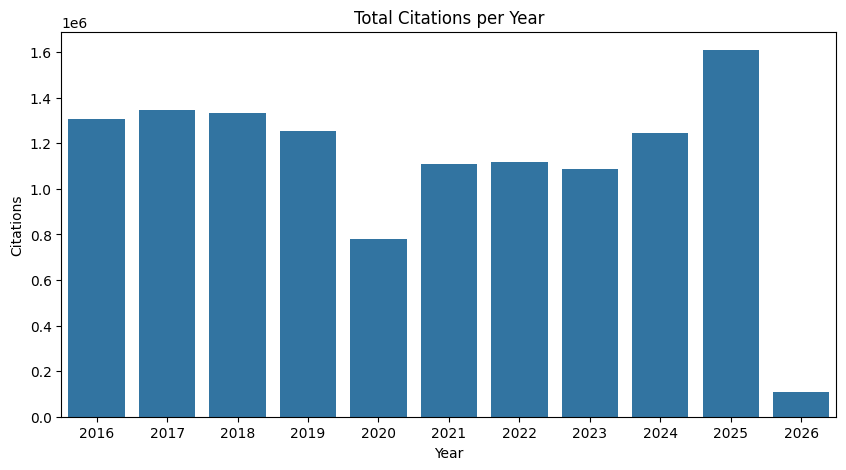

In [52]:
plt.figure(figsize=(10, 5))
sns.barplot(data = yearly,x='year',y='citations')
plt.title("Total Citations per Year")
plt.xlabel("Year")
plt.ylabel("Citations")

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_53994/900928366.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly, x="year", y="pct_change", palette=colors)


Text(0, 0.5, '% Change')

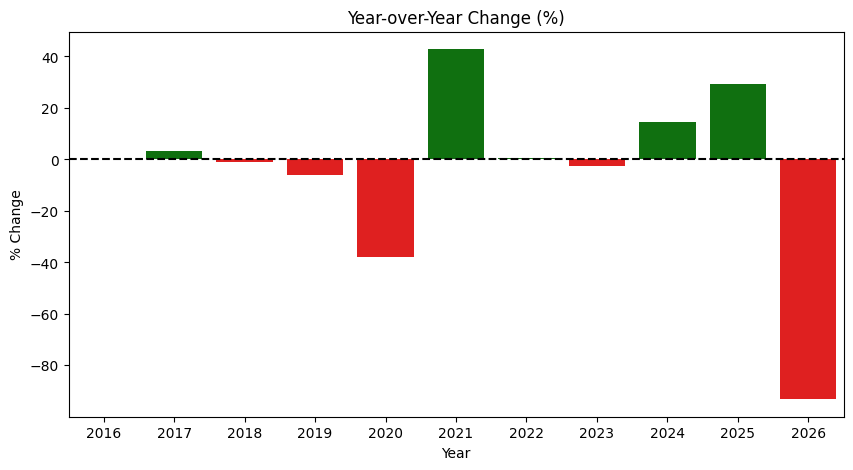

In [53]:
plt.figure(figsize=(10, 5))

colors = ["green" if x >= 0 else "red" for x in yearly["pct_change"]]

sns.barplot(data=yearly, x="year", y="pct_change", palette=colors)

plt.axhline(0, linestyle="--", color="black")

plt.title("Year-over-Year Change (%)")
plt.xlabel("Year")
plt.ylabel("% Change")

In [54]:
hourly = df.groupby('hour').size().reset_index(name='citations').sort_values('hour')

Text(0, 0.5, 'Number of Citations')

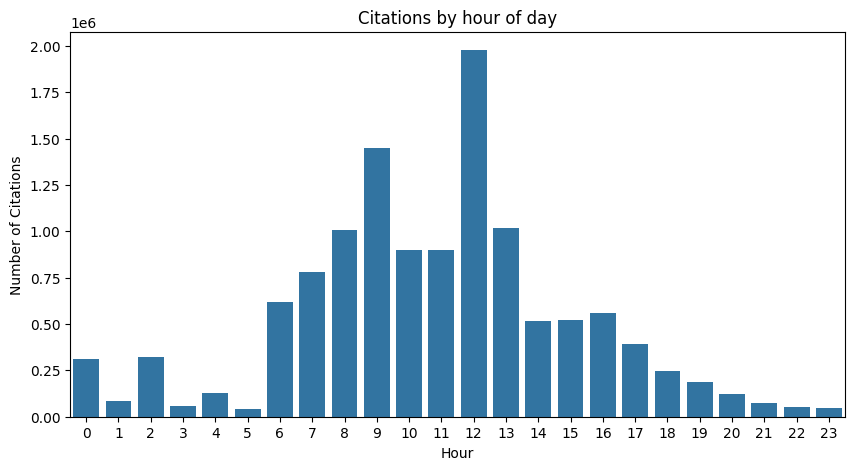

In [55]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data =hourly,
    x='hour',
    y='citations'
)
plt.title("Citations by hour of day")
plt.xlabel("Hour")
plt.ylabel("Number of Citations")

In [56]:
# order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekly = df.groupby('day').size().reset_index(name='count')

# weekly["day_name"] = pd.Categorical(
#     weekly["day_name"],
#     categories=order,
#     ordered=True
# )

# weekly = weekly.sort_values("day_name")

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_53994/905714635.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly = df.groupby('day').size().reset_index(name='count')


Text(0, 0.5, 'Number of Citations')

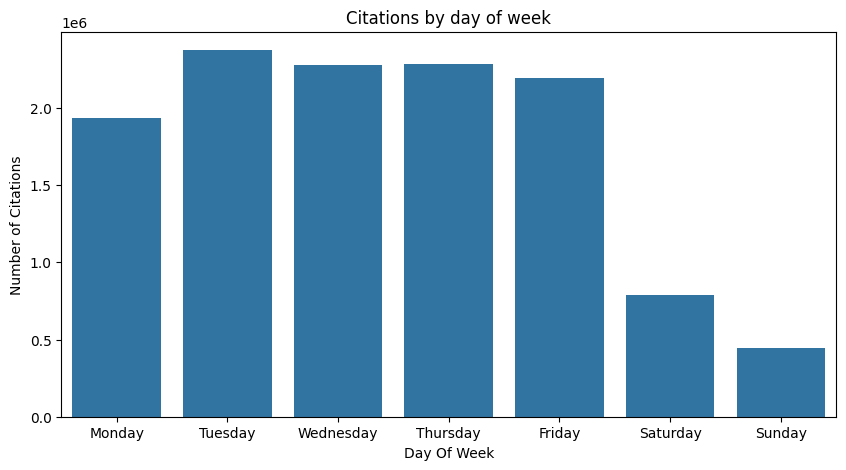

In [57]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data =weekly,
    x='day',
    y='count'
)
plt.title("Citations by day of week")
plt.xlabel("Day Of Week")
plt.ylabel("Number of Citations")

In [58]:
order = ["January", "February", "March", "April", "May", "June", "July", 'August', 'September', 'October','November','December']

monthly = df.groupby('month').size().reset_index(name='count')

monthly["month"] = pd.Categorical(
    monthly["month"],
    categories=order,
    ordered=True
)

monthly = monthly.sort_values("month")

Text(0, 0.5, 'Number of Citations')

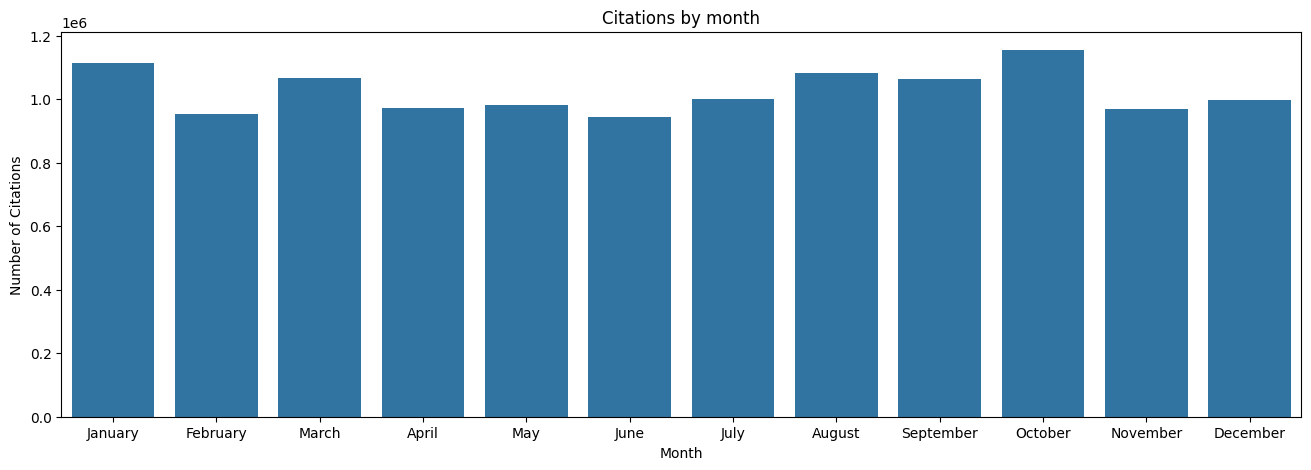

In [59]:
plt.figure(figsize=(16, 5))
sns.barplot(
    data =monthly,
    x='month',
    y='count'
)
plt.title("Citations by month")
plt.xlabel("Month")
plt.ylabel("Number of Citations")

In [60]:
heatmap_data = (
    df.groupby(["hour", "day"])
      .size()
      .unstack(fill_value=0)
)
heatmap_data = heatmap_data.sort_index(ascending=False)

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_53994/4047920594.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["hour", "day"])


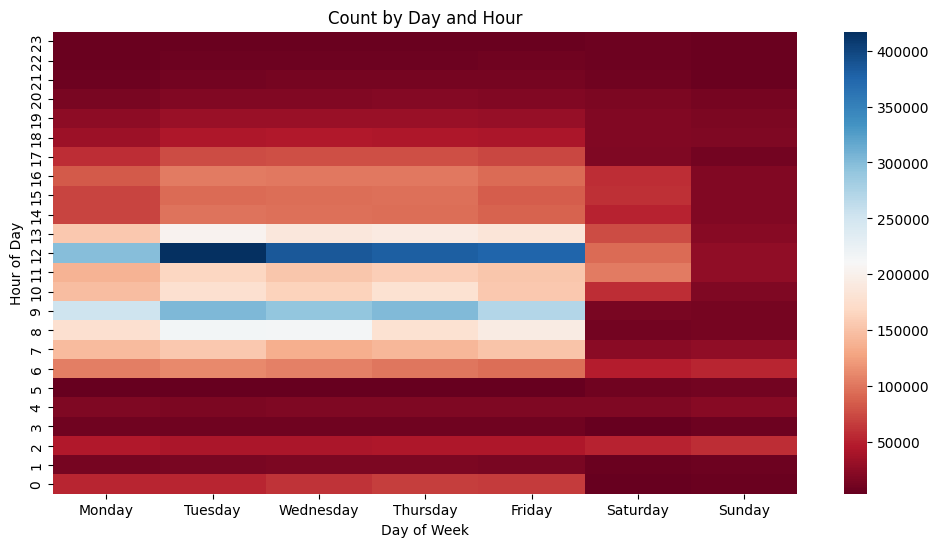

In [61]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="RdBu")

plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.title("Count by Day and Hour")
plt.show()

In [73]:
top_violations = df['Violation Description'].value_counts().head(10).reset_index()
top_violations.columns = ["violation", "count"]

Text(0.5, 1.0, 'Top 10 Most Common Violations')

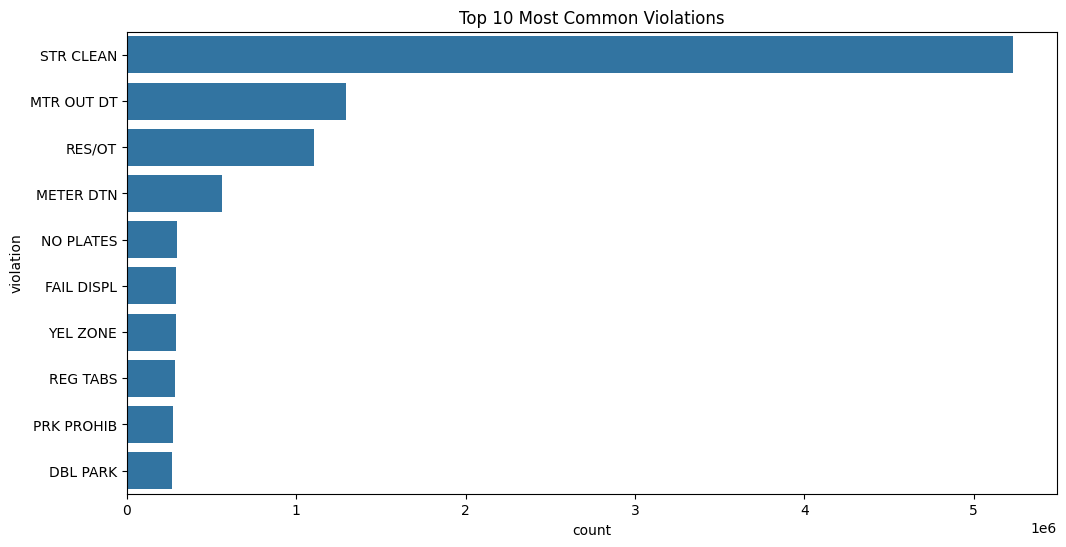

In [75]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_violations, x="count", y="violation")

plt.title("Top 10 Most Common Violations")

In [64]:
yearly_fines = df.groupby('year')['Fine Amount'].sum().reset_index(name='Fine Amount')
yearly_fines

,year,Fine Amount
0,2016,110391713.0
1,2017,119218579.0
2,2018,120999385.0
3,2019,118408552.0
4,2020,70746406.0
5,2021,104761780.0
6,2022,107376875.0
7,2023,107532429.0
8,2024,128374224.0
9,2025,174476465.0


Text(0.5, 0, 'Year')

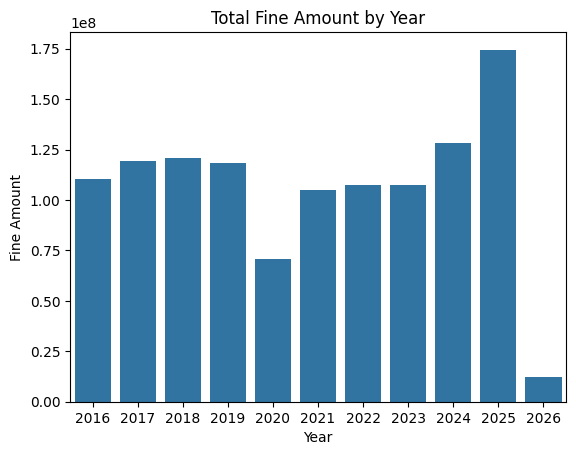

In [65]:
sns.barplot(data=yearly_fines, x="year", y="Fine Amount")

plt.title("Total Fine Amount by Year")
plt.xlabel("Year")

In [76]:
df_top10 = df[df["Violation Description"].isin(top_violations['violation'])]
df_top10


,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude,year,month,hour,day
0,"""11560780T",2026-02-04 19:56:00,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,0.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,Wednesday
1,"""11560776T",2026-02-04 19:52:00,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,0.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,Wednesday
2,"""11561605T",2026-02-04 19:41:00,TRC7.2.101A,FAIL DISPL,METRO FOREST HILL STATION-DOWNTOWN,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,Wednesday
3,"""11553500T",2026-02-04 19:41:00,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,0.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,Wednesday
4,"""998115893",2026-02-04 19:40:00,TRC7.2.40,PRK PROHIB,101 05TH ST,AL,3A0C313,108.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12303666,PD28852762,2016-01-01 23:05:00,V22500H,DBL PARK,TWIN PEAKS,CA,58034P1,110.0,2020 Nov 19 12:00:00 AM,POINT (-122.44223999999997 37.75669000000005),8.0,Castro/Upper Market,POINT(-122.44223999999997 37.75669000000005),POINT(-122.44223999999997 37.75669000000005),2016,January,23,Friday
12303668,PD28547680,2016-01-01 22:50:00,V5204A,REG TABS,BAKER AND POST,CA,7HKN933,121.0,2016 Jan 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2016,January,22,Friday
12303669,PD28547665,2016-01-01 22:49:00,V5204A,REG TABS,2943 BALBOA ST.,CA,5ZQH417,121.0,2020 Jul 28 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2016,January,22,Friday
12303671,PD28547676,2016-01-01 22:45:00,V5204A,REG TABS,2540 POST ST,CA,41924P1,121.0,2016 Jan 01 12:00:00 AM,POINT (-122.44372403399996 37.78409099100003),5.0,Presidio Heights,POINT(-122.44372403399996 37.78409099100003),POINT(-122.44372403399996 37.78409099100003),2016,January,22,Friday


In [77]:
top10_fines = (
    df_top10.groupby("Violation Description")["Fine Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
top10_fines

,Violation Description,Fine Amount
0,STR CLEAN,434963538.0
1,MTR OUT DT,108898267.0
2,RES/OT,102870103.0
3,METER DTN,51998567.0
4,REG TABS,35507579.0
5,NO PLATES,35289570.0
6,FAIL DISPL,32496477.0
7,YEL ZONE,30438515.0
8,PRK PROHIB,29610741.0
9,DBL PARK,28994122.0


Text(0, 0.5, 'Violation')

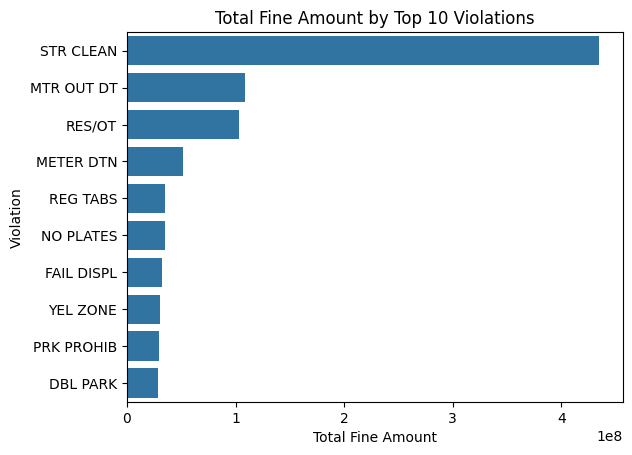

In [78]:
sns.barplot(data=top10_fines, x="Fine Amount", y="Violation Description")

plt.title("Total Fine Amount by Top 10 Violations")
plt.xlabel("Total Fine Amount")
plt.ylabel("Violation")

Text(0, 0.5, 'Count')

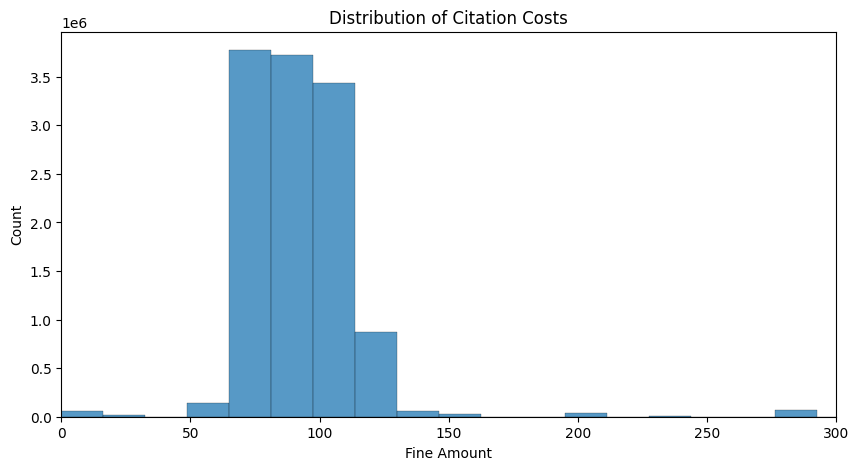

In [85]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Fine Amount"], bins=300)
plt.xlim(0, 300)

plt.title("Distribution of Citation Costs")
plt.xlabel("Fine Amount")
plt.ylabel("Count")

In [ ]:
df.groupby('year')['Fine Amount'].mean()